In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### 1. Data Exploration:

In [17]:
df = pd.read_csv('diabetes.csv')
df.shape

(768, 9)

In [18]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [19]:
df.info()
# the data types of all the features are correct 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [20]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


- maximum number in the 'Pregnancies' lie in the center that is 3
- there is a well ballanced distribution for 'Glucose'. That is No strong skewness
- we could see skewness in columns like 'SkinThickness', 'Insulin'
- the average age feom the data is 33 years old

In [21]:
df.isna().sum()
# there are no null/missing value in the dataset

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

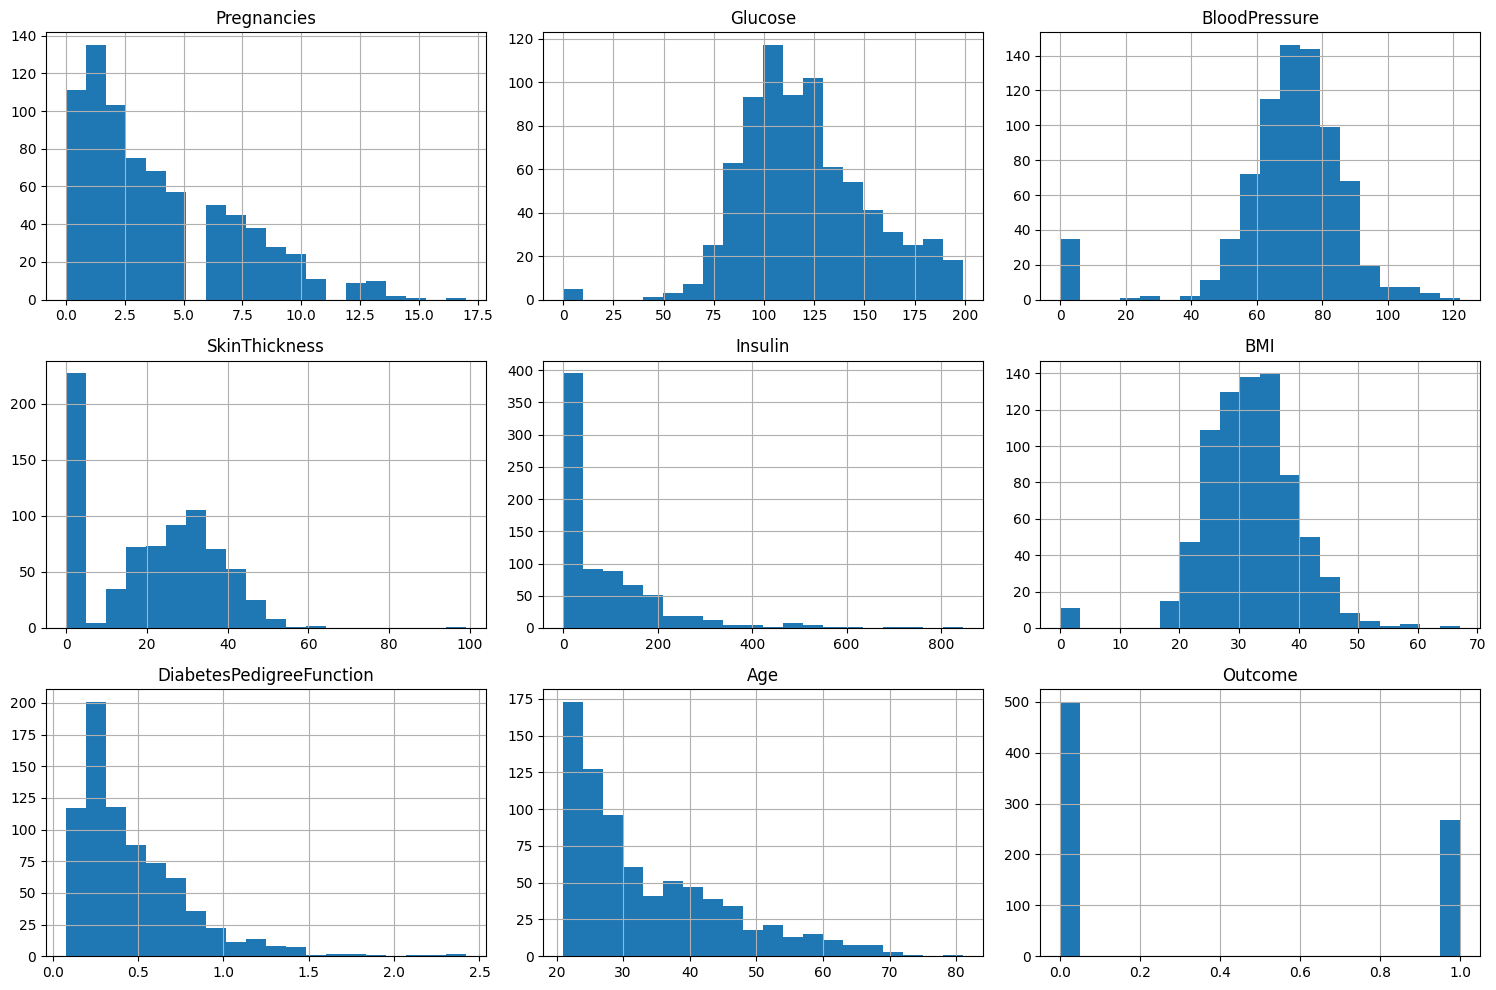

In [22]:
df.hist(figsize=(15, 10), bins=20)
plt.tight_layout()
plt.show()

- from the above graph we can see most of the features are 'right skewed'
- there are some outliers in 'Bloodpressure' and 'BMI', requires preprocessing

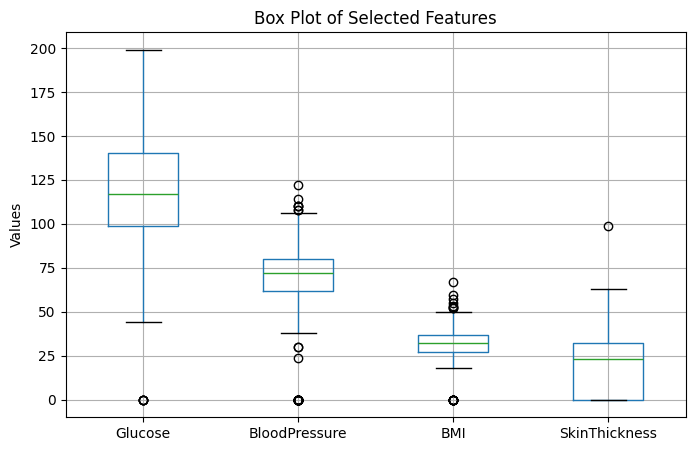

In [23]:
cols = ['Glucose', 'BloodPressure', 'BMI', 'SkinThickness']

df[cols].boxplot(figsize=(8, 5))
plt.title("Box Plot of Selected Features")
plt.ylabel("Values")
plt.show()

In [24]:
# Before analyzing outliers, replace the medically impossible zeros:
cols_out = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_out:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

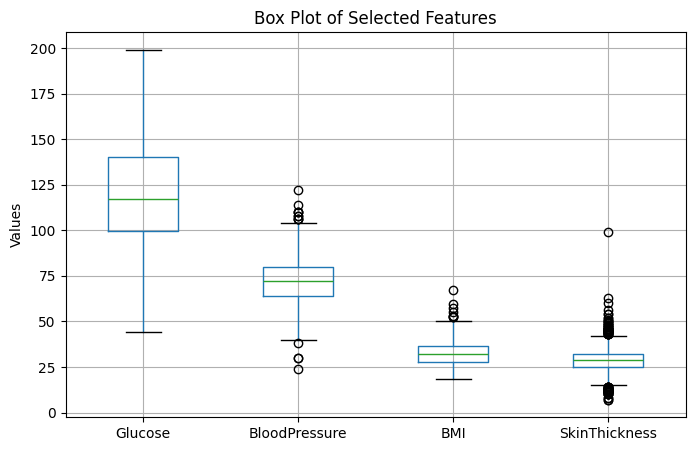

In [25]:
df[cols].boxplot(figsize=(8, 5))
plt.title("Box Plot of Selected Features")
plt.ylabel("Values")
plt.show()

Outlier analysis was performed using box plots. Although several variables contained extreme observations, these values were retained because they represent clinically meaningful measurements rather than data entry errors. Missing values represented by zeros were handled through imputation. For highly skewed features such as Insulin, transformation techniques may be applied to reduce the impact of extreme values while preserving important information.

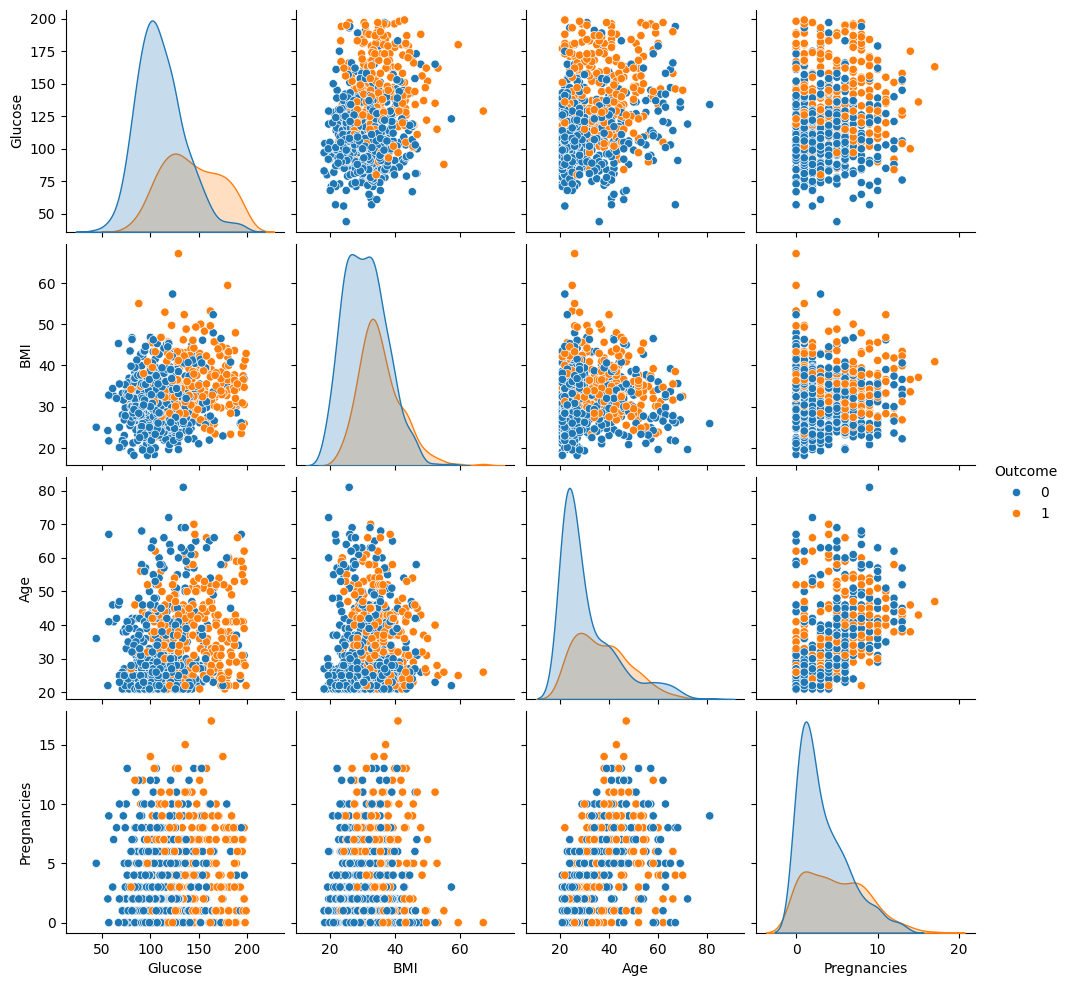

In [27]:
cols_pair = ['Glucose', 'BMI', 'Age', 'Pregnancies']

sns.pairplot(
    df[cols_pair + ['Outcome']],
    hue='Outcome'
)

plt.show()

- Glucose shows the strongest relationship with diabetes outcome. Diabetic patients generally exhibit higher glucose levels than non-diabetic patients.
- BMI demonstrates a moderate association with diabetes. Patients with higher BMI values appear more likely to be diabetic, although the classes are not clearly separable using BMI alone.
- Age exhibits a positive relationship with diabetes occurrence. Older individuals show a higher prevalence of diabetes compared to younger individuals.

#### 3. Model Building:

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import roc_auc_score

In [29]:
x = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']]
y = df['Outcome']

In [30]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [31]:
model = LogisticRegression()

In [32]:
model.fit(x_train, y_train)

C:\Users\Basavaraj M\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [40]:
# y_train_pred = model.predict(x_train)
y_pred = model.predict(x_test)

#### 4. Model Evaluation:

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.7445887445887446

In [42]:
cm = confusion_matrix(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()

In [45]:
class_report = classification_report(y_test, y_pred) # find what does it do

In [46]:
print(class_report)

              precision    recall  f1-score   support

           0       0.79      0.82      0.81       151
           1       0.64      0.60      0.62        80

    accuracy                           0.74       231
   macro avg       0.72      0.71      0.71       231
weighted avg       0.74      0.74      0.74       231



In [ ]:
# ROC-AUC (probabilities)
y_prob = model.predict_proba(x_test)[:, 1]

In [49]:
roc_auc = roc_auc_score(y_test, y_prob)
roc_auc

np.float64(0.8048841059602648)

Text(0, 0.5, 'TPR')

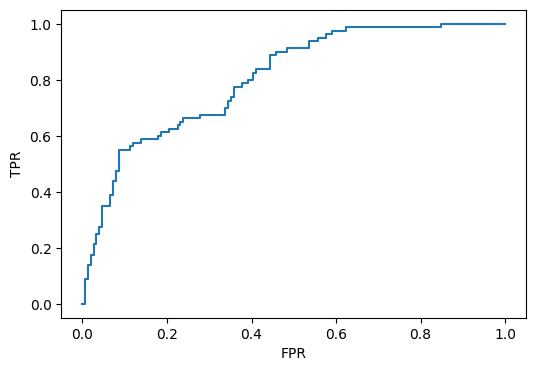

In [53]:
# roc curve and auc
fpr, tpr, thresholds = roc_curve(y_test ,y_prob)
roc_auc = auc(fpr, tpr)

#plot
plt.figure(figsize =(6,4))
plt.plot(fpr, tpr, label="Roc curve(area=%0.2f)"%roc_auc)
plt.xlabel("FPR")
plt.ylabel("TPR")

In [54]:
print(model.coef_)
print(model.intercept_)

[[ 6.41224876e-02  3.93245713e-02 -1.11119844e-02  2.09627223e-03
  -6.51959574e-04  1.05143341e-01  7.58515578e-01  3.20961512e-02]]
[-9.87598825]


A - The Logistic Regression model achieved an accuracy of 74.46% on the test dataset. The model obtained a precision of 64%, indicating that when it predicts diabetes, 64% of those predictions are correct. The recall of 60% shows that the model correctly identifies 60% of actual diabetic patients. The F1-score of 62% reflects a reasonable balance between precision and recall. The ROC-AUC score of 0.805 indicates good discrimination ability, meaning the model can effectively distinguish between diabetic and non-diabetic patients.

B - The significance of a feature is determined by the magnitude and sign of its coefficient in the Logistic Regression model. Features with larger absolute coefficients have a greater impact on predicting the target variable. Positive coefficients increase the probability of the target event occurring, while negative coefficients decrease it.

#### 6. Deployment with Streamlit:

In [ ]:
import joblib

In [56]:
# save the model
joblib.dump(model, 'model.pkl')

['model.pkl']

### Interview Questions:

1.What is the difference between precision and recall?

- Precision and Recall are evaluation metrics used to measure the performance of a binary classification model.

- Precision measures the proportion of correctly predicted positive instances out of all instances predicted as positive. It indicates how accurate the positive predictions are.
  - Precision = True Positives / (True Positives + False Positives)

- Recall measures the proportion of correctly predicted positive instances out of all actual positive instances. It indicates how well the model identifies positive cases.
  - Recall = True Positives / (True Positives + False Negatives)

Difference between Precision and Recall:

1) Precision focuses on the accuracy of positive predictions.
2) Recall focuses on capturing all actual positive instances.
3) High precision means fewer false positives.
4) High recall means fewer false negatives.

2.What is cross-validation, and why is it important in binary classification?

- Cross-validation is a model evaluation technique used to assess the performance and generalization ability of a machine learning model. It involves dividing the dataset into multiple subsets (folds), training the model on some folds, and testing it on the remaining fold. This process is repeated several times, and the results are averaged.
- The most commonly used method is k-Fold Cross-Validation, where the dataset is divided into k equal parts. The model is trained k times, each time using a different fold as the test set and the remaining folds as the training set.

Importance in Binary Classification:

1) Provides a more reliable estimate of model performance.
2) Reduces the risk of overfitting.
3) Ensures that all data points are used for both training and testing.
4) Helps in selecting the best model and tuning hyperparameters.
5) Produces a more robust evaluation compared to a single train-test split.

Therefore, cross-validation helps determine how well a binary classification model is likely to perform on unseen data.